In [1]:
# Library imports and params
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import interpolate
import glob
import csv

## Defining the fonts before plotting:

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "monospace",  # Use monospace font
    "text.latex.preamble": r"\usepackage{courier}"  # Use Courier font
})
mpl.rcParams.update(mpl.rcParamsDefault)

plt.rcParams.update({
    'font.family': 'monospace',  # monospace font
    "text.latex.preamble": r"\usepackage{courier}",
    'font.size': 20,
    'axes.titlesize': 20,
    'axes.labelsize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 20,
    'figure.titlesize': 20,
})

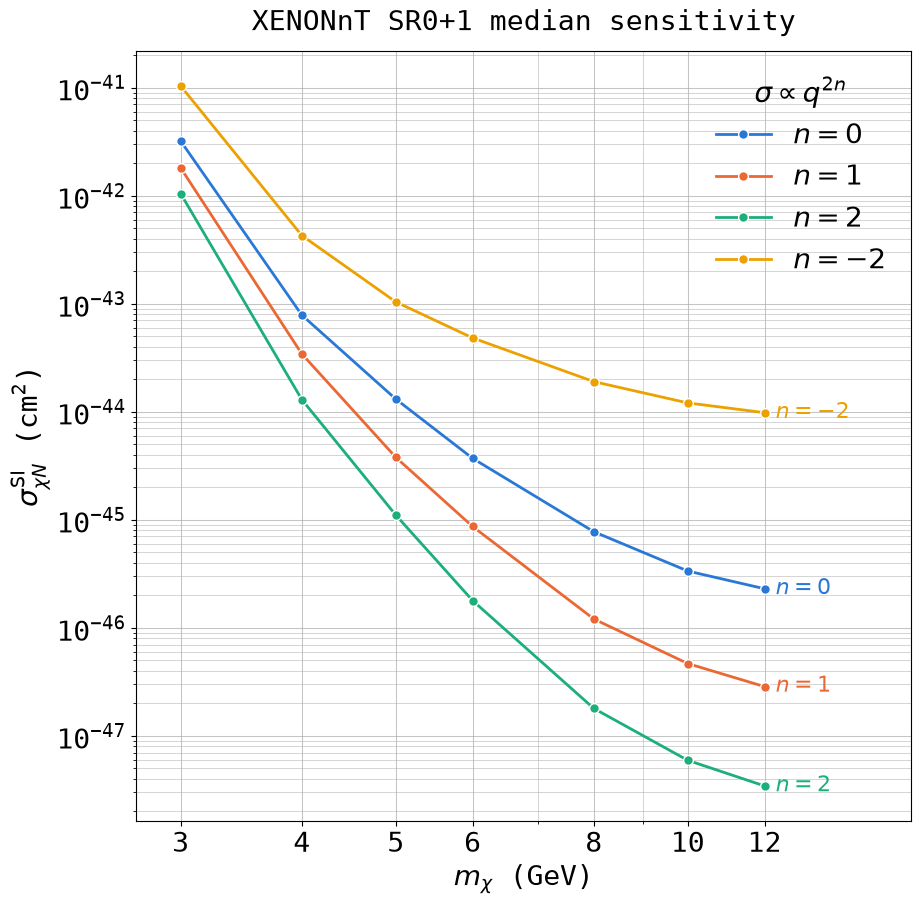

In [2]:
### XENONnT light-WIMP limits (FIG 3 of arXiv:2409.17868), median sensitivity only

limits_dir_XENONnT = ("data/XENONnT-light_wimp_data_release-64d2e13/"
                      "light_wimp_data_release/limits")

# Fixed order -> fixed colours, so a curve keeps its colour if one is dropped:
XENONnT_operators = [
    ("si",      r"$n = 0$",  '#2a78d6'),   # standard SI, q-independent
    ("si_n_1",  r"$n = 1$",  '#eb6834'),
    ("si_n_2",  r"$n = 2$",  '#1baf7a'),
    ("si_n_m2", r"$n = -2$", '#eda100'),
]

# Columns: 0 index, 1 median, 2 2ul, 3 ul, 4 dl, 5 2dl, 6 wimp_mass
dd_limits_XENONnT = {}
for tag, label, colour in XENONnT_operators:
    fname = f"{limits_dir_XENONnT}/XENONnT_SR0+1_light_WIMP_v11_as_cevns_{tag}_1.17_2.34.csv"
    data_XENONnT = np.loadtxt(fname, delimiter=',', skiprows=1)
    dd_limits_XENONnT[tag] = (data_XENONnT[:, 6],      # WIMP mass, GeV
                              data_XENONnT[:, 1])      # median limit, cm^2

## Creating a plot:

fig, ax = plt.subplots(figsize=(10, 10))

ax.set_xlabel(r"$m_\chi$ (GeV)")
ax.set_ylabel(r"$\sigma^{\rm SI}_{\chi N}$ (cm$^2$)")
ax.set_title(r"XENONnT SR0+1 median sensitivity", pad=15)

## Log Axis
ax.set_xscale('log')
ax.set_yscale('log')

## Major grid:
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.75)

## Minor ticks and grid:
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.5, alpha=0.75)

ax.set_axisbelow(True) # Ensure grid is below data

for tag, label, colour in XENONnT_operators:
    mchi_XENONnT, sigma_XENONnT = dd_limits_XENONnT[tag]
    ax.plot(mchi_XENONnT, sigma_XENONnT,
            color = colour,
            linewidth = 2,
            marker = 'o',
            markersize = 7,
            markeredgecolor = 'white',
            markeredgewidth = 1.0,
            label = label,
            zorder = 3)
    # Direct label at the right-hand end of each curve:
    ax.annotate(label,
                xy = (mchi_XENONnT[-1], sigma_XENONnT[-1]),
                xytext = (8, 0), textcoords = 'offset points',
                color = colour, fontsize = 16, va = 'center', ha = 'left')

# Plain tick labels over the narrow 3-12 GeV decade:
ax.set_xticks([3, 4, 5, 6, 8, 10, 12])
ax.set_xticklabels(['3', '4', '5', '6', '8', '10', '12'])
ax.set_xlim(2.7, 17)

ax.legend(title = r"$\sigma \propto q^{2n}$", frameon = False, loc = 'upper right')

# Show the figure:
plt.show()


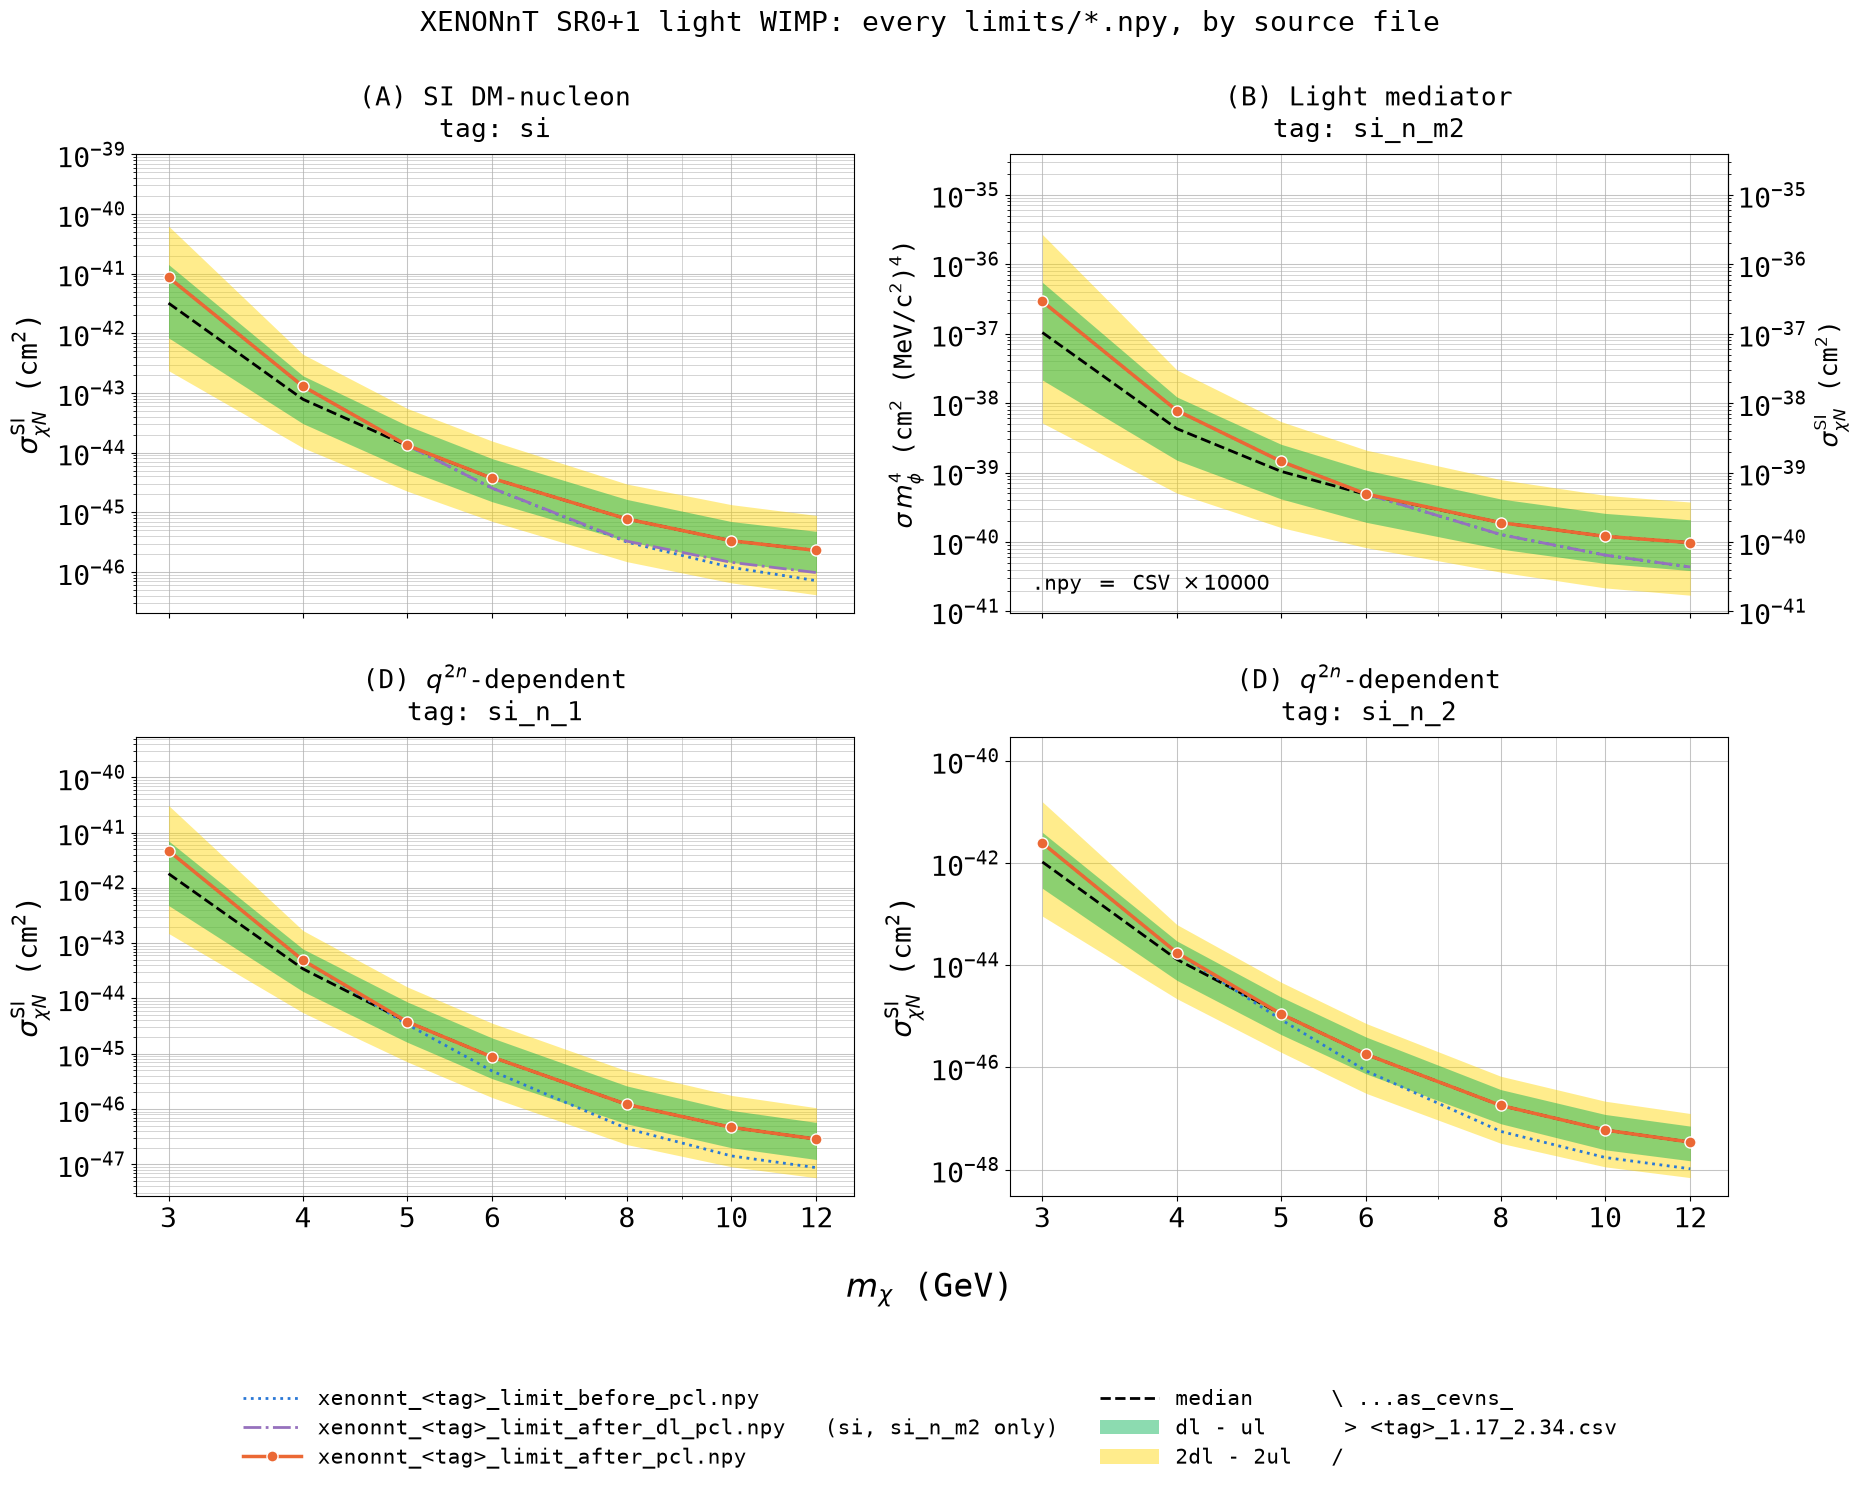

In [3]:
### XENONnT light-WIMP limits: mapping the .npy files onto FIG 3 of arXiv:2409.17868
###
### `limits/` holds 10 .npy files (the FIG 3 data points) + 4 CSVs (the sensitivity
### bands). This figure plots every .npy so it is visible which file holds which
### curve: one panel per <tag>, and the shared legend names the file pattern.
###
### Panel map:  si -> FIG 3 (A)   si_n_m2 -> (B)   si_n_1, si_n_2 -> (D)
### FIG 3 (C), SD DM-neutron scattering, has no .npy in this release.

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

XENONnT_panels = [
    ("si",      "(A) SI DM-nucleon"),
    ("si_n_m2", "(B) Light mediator"),
    ("si_n_1",  "(D) $q^{2n}$-dependent"),
    ("si_n_2",  "(D) $q^{2n}$-dependent"),
]

# Fixed colour per *file role*, identical in every panel, so one shared legend
# doubles as a lookup table from curve to filename:
XENONnT_pcl_variants = [
    ("before_pcl",   '#2a78d6', ':',  2.0, None),
    ("after_dl_pcl", '#9671bd', '-.', 2.0, None),
    ("after_pcl",    '#eb6834', '-',  2.5, 'o'),
]

band_1sigma_colour = '#00b050'   # conventional +-1 sigma sensitivity band
band_2sigma_colour = '#ffd700'   # conventional +-2 sigma sensitivity band

# Columns: 0 index, 1 median, 2 2ul, 3 ul, 4 dl, 5 2dl, 6 wimp_mass
bands_XENONnT, observed_XENONnT, npy_scale = {}, {}, {}
for tag, panel in XENONnT_panels:
    fname = f"{limits_dir_XENONnT}/XENONnT_SR0+1_light_WIMP_v11_as_cevns_{tag}_1.17_2.34.csv"
    csv_XENONnT = np.loadtxt(fname, delimiter=',', skiprows=1)
    bands_XENONnT[tag] = dict(mass = csv_XENONnT[:, 6],
                              median = csv_XENONnT[:, 1],
                              ul2 = csv_XENONnT[:, 2], ul = csv_XENONnT[:, 3],
                              dl = csv_XENONnT[:, 4], dl2 = csv_XENONnT[:, 5])

    # after_dl_pcl only exists for si and si_n_m2, hence the try:
    obs = {}
    for variant, *_ in XENONnT_pcl_variants:
        try:
            arr = np.load(f"{limits_dir_XENONnT}/xenonnt_{tag}_limit_{variant}.npy")
        except FileNotFoundError:
            continue
        obs[variant] = (arr['mass_gev'], arr['limit_cm2'])
    observed_XENONnT[tag] = obs

    # Recover the .npy/CSV unit factor from the power-constraint identity
    # after_pcl = max(before_pcl, scale * median), using the masses where the
    # constraint actually bites (there after_pcl is exactly scale * median).
    # It comes out 1 everywhere except si_n_m2, the light-mediator case, whose
    # .npy carries FIG 3 (B)'s right-hand axis: sigma_SI * (10 MeV)^4 = 1e4 x cm^2.
    before, after = obs['before_pcl'][1], obs['after_pcl'][1]
    saturated = after > before*(1 + 1e-9)
    npy_scale[tag] = np.median(after[saturated] / csv_XENONnT[saturated, 1])

## Creating a plot: 2x2 small multiples, shared mass axis, own cross-section axis

fig, axes = plt.subplots(2, 2, figsize=(19, 15), sharex=True)

for ax, (tag, panel) in zip(axes.flat, XENONnT_panels):
    band, obs, scale = bands_XENONnT[tag], observed_XENONnT[tag], npy_scale[tag]
    light_mediator = not np.isclose(scale, 1.0)   # only si_n_m2

    ## Log Axis
    ax.set_xscale('log')
    ax.set_yscale('log')

    ## Major grid:
    ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.75)

    ## Minor ticks and grid:
    ax.minorticks_on()
    ax.grid(True, which='minor', linestyle='-', linewidth=0.5, alpha=0.75)

    ax.set_axisbelow(True) # Ensure grid is below data

    # Bands are drawn in the .npy's units so the two sources overlay:
    ax.fill_between(band['mass'], scale*band['dl2'], scale*band['ul2'],
                    color = band_2sigma_colour, alpha = 0.45,
                    linewidth = 0, zorder = 1)
    ax.fill_between(band['mass'], scale*band['dl'], scale*band['ul'],
                    color = band_1sigma_colour, alpha = 0.45,
                    linewidth = 0, zorder = 2)
    ax.plot(band['mass'], scale*band['median'],
            color = 'black', linewidth = 2, linestyle = '--', zorder = 3)

    for z, (variant, colour, style, width, marker) in enumerate(XENONnT_pcl_variants):
        if variant not in obs:
            continue
        mchi_XENONnT, sigma_XENONnT = obs[variant]
        ax.plot(mchi_XENONnT, sigma_XENONnT,
                color = colour,
                linewidth = width,
                linestyle = style,
                marker = marker,
                markersize = 8,
                markeredgecolor = 'white',
                markeredgewidth = 1.0,
                zorder = 4 + z)

    ax.set_title(f"{panel}\ntag: {tag}", pad = 12, fontsize = 19)

    # FIG 3 (B) is the light-mediator panel: its .npy is in cm^2 (MeV/c^2)^4, so
    # give it the paper's second axis carrying cm^2.
    if light_mediator:
        ax.set_ylabel(r"$\sigma \, m_\phi^4$ (cm$^2$ (MeV/c$^2$)$^4$)", fontsize=18)
        twin = ax.secondary_yaxis('right', functions=(lambda y: y/scale,
                                                      lambda y: y*scale))
        twin.set_ylabel(r"$\sigma^{\rm SI}_{\chi N}$ (cm$^2$)", fontsize=18)
        ax.annotate(rf".npy $=$ CSV $\times\,{scale:.0f}$", fontsize = 15,
                    xy = (0.03, 0.05), xycoords = 'axes fraction')
    else:
        ax.set_ylabel(r"$\sigma^{\rm SI}_{\chi N}$ (cm$^2$)")

    # Plain tick labels over the narrow 3-12 GeV decade:
    ax.set_xticks([3, 4, 5, 6, 8, 10, 12])
    ax.set_xticklabels(['3', '4', '5', '6', '8', '10', '12'])
    ax.set_xlim(2.8, 13)
    ax.set_ylim(top = ax.get_ylim()[1]*8)   # headroom so no curve hugs the frame

fig.supxlabel(r"$m_\chi$ (GeV)", y = 0.125)
fig.suptitle("XENONnT SR0+1 light WIMP: every limits/*.npy, by source file", y = 0.99)

## Setting a costumised legend: colour+style mean the same file role in every
## panel, so the <tag> placeholder resolves via each panel's title.
legend_handles = [
    Line2D([], [], color = c, linestyle = s, linewidth = w, marker = m,
           markersize = 8, markeredgecolor = 'white',
           label = f"xenonnt_<tag>_limit_{variant}.npy"
                   + ("   (si, si_n_m2 only)" if variant == "after_dl_pcl" else ""))
    for variant, c, s, w, m in XENONnT_pcl_variants
] + [
    Line2D([], [], color = 'black', linestyle = '--', linewidth = 2,
           label = "median      \\ ...as_cevns_"),
    Patch(facecolor = band_1sigma_colour, alpha = 0.45,
          label = "dl - ul      > <tag>_1.17_2.34.csv"),
    Patch(facecolor = band_2sigma_colour, alpha = 0.45,
          label = "2dl - 2ul   /"),
]

fig.legend(
    handles = legend_handles,
    loc = 'lower center',
    bbox_to_anchor = (0.5, 0.005),
    ncol = 2,                      # spread horizontally
    frameon = False,               # removes legend border
    fontsize = 15,
    handlelength = 2.8,
    labelspacing = 0.4
)

fig.tight_layout(rect=[0, 0.11, 1, 1])

# Show the figure:
plt.show()

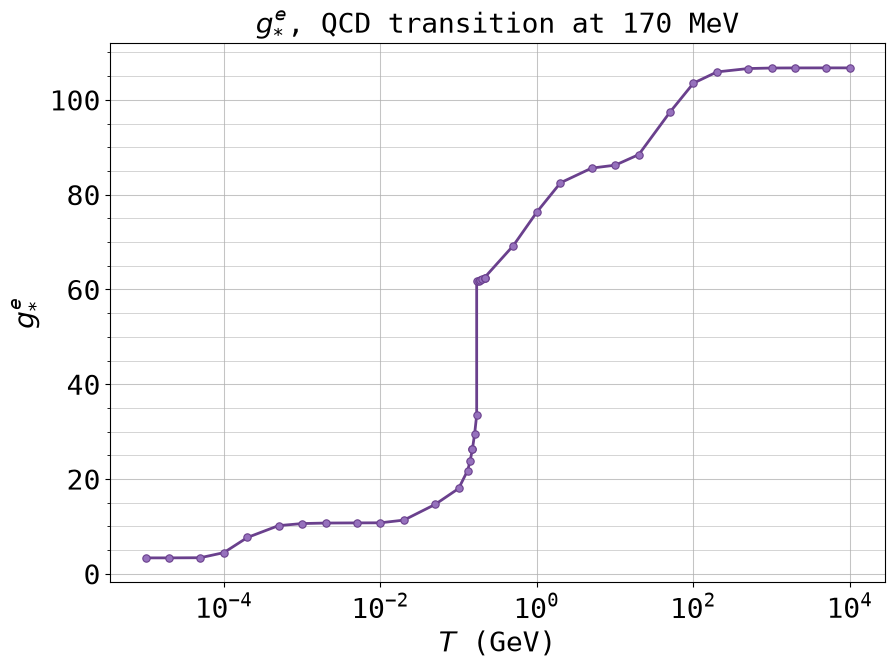

In [ ]:
### Effective degrees of freedom in the energy density, g*_e(T),
### from data/effective_dof.csv.

# The QCD transition temperature is not settled, so the table lists the
# 150-214 MeV window once per candidate, tagged in the last column by which
# choice(s) the row belongs to ('All' outside the window). Pick one, or g*_e
# is double valued at seven temperatures.
qcd_transition = "170"          # "214", "170" or "150" MeV

dof_table = np.genfromtxt("data/effective_dof.csv", delimiter=',', names=True,
                          dtype=None, encoding='utf-8')

keep_dof = np.array([m == "All" or qcd_transition in m
                     for m in dof_table["transition_temperature_model"]])

T_dof = dof_table["kBT_eV"][keep_dof]*1e-9        # eV -> GeV
gstar_e = dof_table["g_star_e"][keep_dof]

# Sort on (T, g*_e), not T alone: the transition is a genuine discontinuity,
# with the '-' and '+' rows sharing one temperature. g*_e grows with T, so
# breaking the tie on g*_e puts the lower branch first; sorting on T alone
# leaves those two in arbitrary order and can draw the jump backwards.
order = np.lexsort((gstar_e, T_dof))
T_dof, gstar_e = T_dof[order], gstar_e[order]

## Creating a plot:

fig, ax = plt.subplots(figsize=(10, 7))

ax.set_xlabel(r"$T$ (GeV)")
ax.set_ylabel(r"$g_{*}^{e}$")

ax.set_xscale('log')            # T spans 9 decades; g*_e only a factor ~30

ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.75)
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.5, alpha=0.75)
ax.set_axisbelow(True)

ax.plot(T_dof, gstar_e, color='#6a408d', linewidth=2.0, zorder=2)
ax.scatter(T_dof, gstar_e, s=28, color='#9671bd', edgecolors='#6a408d',
           linewidths=0.8, zorder=3)

ax.set_title(r"$g_{*}^{e}$, QCD transition at " + qcd_transition + r" MeV",
             fontsize=20)

#plt.savefig("figures/effective_dof_check.pdf", bbox_inches='tight')
plt.show()

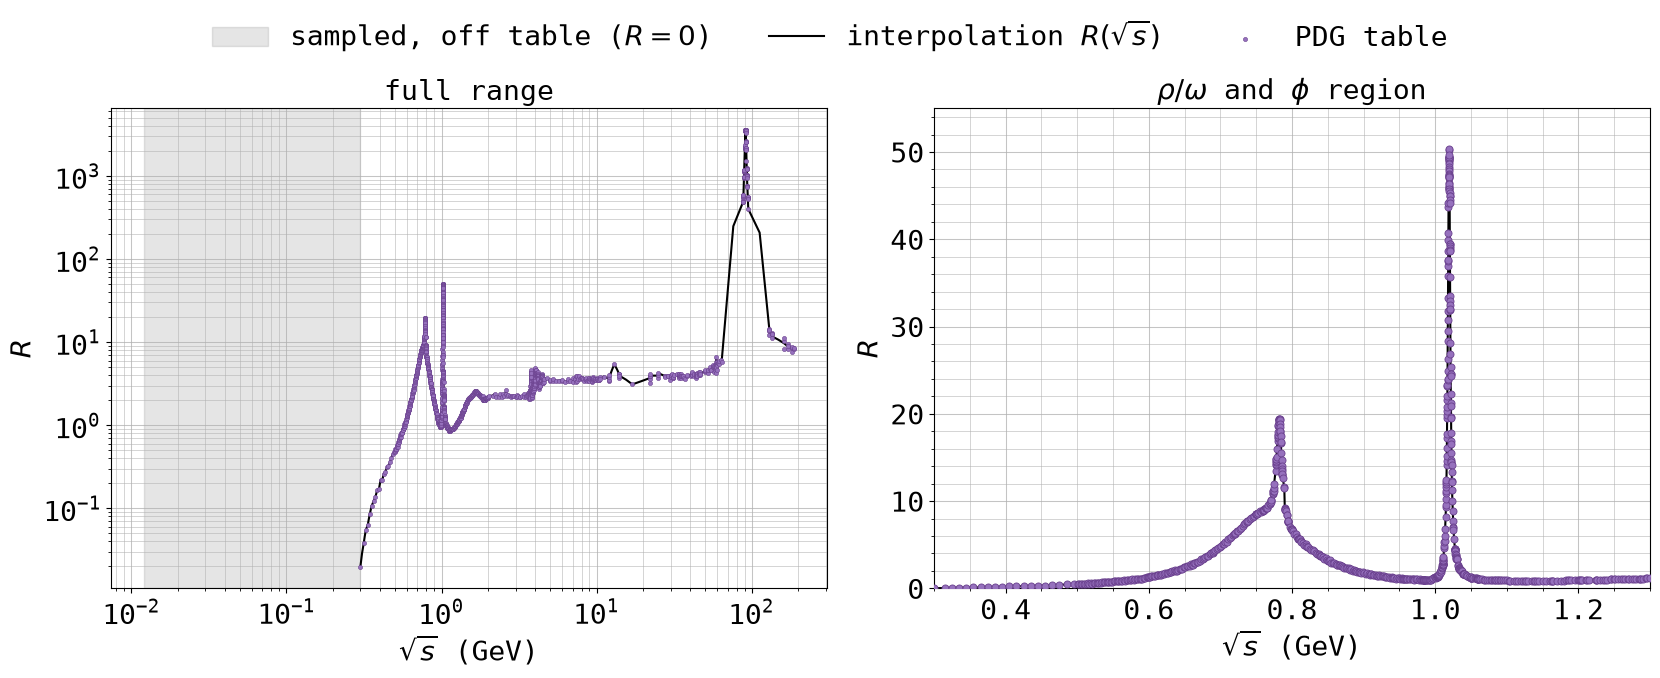

In [6]:
### Hadronic R ratio, R = sigma(e+e- -> hadrons)/sigma(e+e- -> mu+mu-),
### from the PDG compilation in data/rratio.dat (1400 points, 0.3-188.7 GeV).

def read_rratio(path="data/rratio.dat"):
    """Read the PDG R-ratio table -> (E_cm, R, dR).

    Fixed-width, per the FORTRAN format documented at the foot of the file
    (f10.5,2x,f10.5,1x,f10.5,2x,f10.5,2x,sp,f10.5,1x,f10.5,...): E(cm) at
    [0:10], R at [35:45], +stat at [47:57], -stat at [58:68].

    Lines whose E(cm) field is blank carry extra systematics for the
    preceding point rather than a new point, and are skipped. They must be
    read by column, not by str.split(): their first non-blank token is a
    signed systematic like '+5.10', which splitting would happily mistake
    for an energy.
    """
    E, R, dR = [], [], []
    with open(path) as f:
        for line in f:
            if line.startswith("*") or not line.strip():
                continue
            try:
                ecm = float(line[0:10])
            except ValueError:
                continue                                  # continuation line
            if ecm <= 0.0:
                continue
            E.append(ecm)
            R.append(float(line[35:45]))
            dR.append(0.5*(abs(float(line[47:57])) + abs(float(line[58:68]))))
    return np.array(E), np.array(R), np.array(dR)

ecm_rratio, Rdata, dRdata = read_rratio()

# 70 energies are quoted by more than one experiment, but interp1d needs a
# strictly increasing x, so repeats are collapsed into a single
# inverse-variance weighted mean (the stat errors are all non-zero).
weights_R = 1.0/dRdata**2
ecm_R, index_R = np.unique(ecm_rratio, return_inverse=True)
R_R = (np.bincount(index_R, weights=weights_R*Rdata)
       / np.bincount(index_R, weights=weights_R))

# Linear in both E and R: the table is dense and full of resonances (rho,
# J/psi, Upsilon, Z), whose peaks a log-log interpolation would distort.
R_interp = interpolate.interp1d(ecm_R, R_R)

def R(sqrts):
    """Hadronic R ratio at sqrt(s), interpolated from the PDG table.

    Below the first tabulated point (0.3 GeV, just above the 2*mpi hadronic
    threshold) there is nothing to produce, so R = 0. That is also what keeps
    RKmu finite: 0.3/2 = 0.15 GeV > m_mu, so wherever R != 0 the un-cut Kmu
    is evaluated above the muon mass. Above the last point (188.7 GeV) the
    value is held flat, which the plots never reach.
    """
    sqrts = np.asarray(sqrts, dtype=float)
    inside = sqrts >= ecm_R[0]
    return np.where(inside, R_interp(np.clip(sqrts, ecm_R[0], ecm_R[-1])), 0.0)


ma = np.logspace(-2, 2, 10000)  # Mass range from 0.1 GeV to 1000 GeV

mchi = 0.6*ma

## Checking the R interpolation against the tabulated PDG points.

# The interpolant is piecewise linear, so evaluating it at the nodes AND at
# every midpoint draws it exactly: any daylight between the line and the
# markers is a real problem, not a sampling artefact.
ecm_dense = np.sort(np.concatenate([ecm_R, 0.5*(ecm_R[:-1] + ecm_R[1:])]))

fig, (ax_full, ax_zoom) = plt.subplots(1, 2, figsize=(17, 6.5))

for ax in (ax_full, ax_zoom):
    ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.75)
    ax.minorticks_on()
    ax.grid(True, which='minor', linestyle='-', linewidth=0.5, alpha=0.75)
    ax.set_axisbelow(True)
    ax.set_xlabel(r"$\sqrt{s}$ (GeV)")
    ax.set_ylabel(r"$R$")

## Left: the whole table, log-log (R spans 0.02 to 3540 across the Z pole).
ax_full.set_xscale('log')
ax_full.set_yscale('log')
ax_full.set_xbound(1e-2, 2.2e2)

# The relic curve samples down to sqrt(s) = 2*min(mchi), well below the first
# tabulated point, so flag the stretch that is off the table and set to R = 0:
ax_full.axvspan(2*mchi.min(), ecm_R[0], color='#7e7e7e', alpha=0.20,
                zorder=0, label=r"sampled, off table ($R=0$)")

ax_full.plot(ecm_dense, R(ecm_dense), color='black', linewidth=1.5,
             zorder=2, label=r"interpolation $R(\sqrt{s})$")
ax_full.scatter(ecm_rratio, Rdata, s=9, color='#9671bd', edgecolors='#6a408d',
                linewidths=0.4, zorder=3, label=r"PDG table")
ax_full.set_title(r"full range", fontsize=20)

## Right: zoom on the light resonances, where the structure is narrowest
## relative to the node spacing and the interpolation is most likely to fail.
ax_zoom.plot(ecm_dense, R(ecm_dense), color='black', linewidth=1.5, zorder=2)
ax_zoom.scatter(ecm_rratio, Rdata, s=26, color='#9671bd', edgecolors='#6a408d',
                linewidths=0.6, zorder=3)
ax_zoom.set_xbound(0.3, 1.3)
ax_zoom.set_ybound(0, 55)
ax_zoom.set_title(r"$\rho/\omega$ and $\phi$ region", fontsize=20)

handles, labels = ax_full.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.08),
           ncol=3, frameon=False)

fig.tight_layout()
#plt.savefig("figures/rratio_interpolation_check.pdf", bbox_inches='tight')
plt.show()